In [2]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Database connection
conn = sqlite3.connect("college.db")

In [4]:
query = """
SELECT name
FROM sqlite_master
WHERE type='table';
"""

tables = pd.read_sql_query(query, conn)

print(tables)

Empty DataFrame
Columns: [name]
Index: []


In [5]:
students_data = {
    'student_id': [1,2,3,4,5,6,7,8],

    'name': [
        'Oviya','Rahul','Ananya','Kavin',
        'Priya','Arun','Meena','Surya'
    ],

    'department': [
        'CS','EC','ME','CE',
        'CS','EC','ME','CE'
    ],

    'gender': [
        'Female','Male','Female','Male',
        'Female','Male','Female','Male'
    ],

    'math_score': [95,80,78,88,92,75,81,89],

    'programming_score': [98,70,65,85,90,72,60,87],

    'attendance_percentage': [90,85,88,92,95,80,84,91]
}

students_df = pd.DataFrame(students_data)

# Create total_score
students_df['total_score'] = (
    students_df['math_score']
    + students_df['programming_score']
)

# Store table
students_df.to_sql(
    'students',
    conn,
    if_exists='replace',
    index=False
)

print(students_df)

   student_id    name department  gender  math_score  programming_score  \
0           1   Oviya         CS  Female          95                 98   
1           2   Rahul         EC    Male          80                 70   
2           3  Ananya         ME  Female          78                 65   
3           4   Kavin         CE    Male          88                 85   
4           5   Priya         CS  Female          92                 90   
5           6    Arun         EC    Male          75                 72   
6           7   Meena         ME  Female          81                 60   
7           8   Surya         CE    Male          89                 87   

   attendance_percentage  total_score  
0                     90          193  
1                     85          150  
2                     88          143  
3                     92          173  
4                     95          182  
5                     80          147  
6                     84          141  
7   

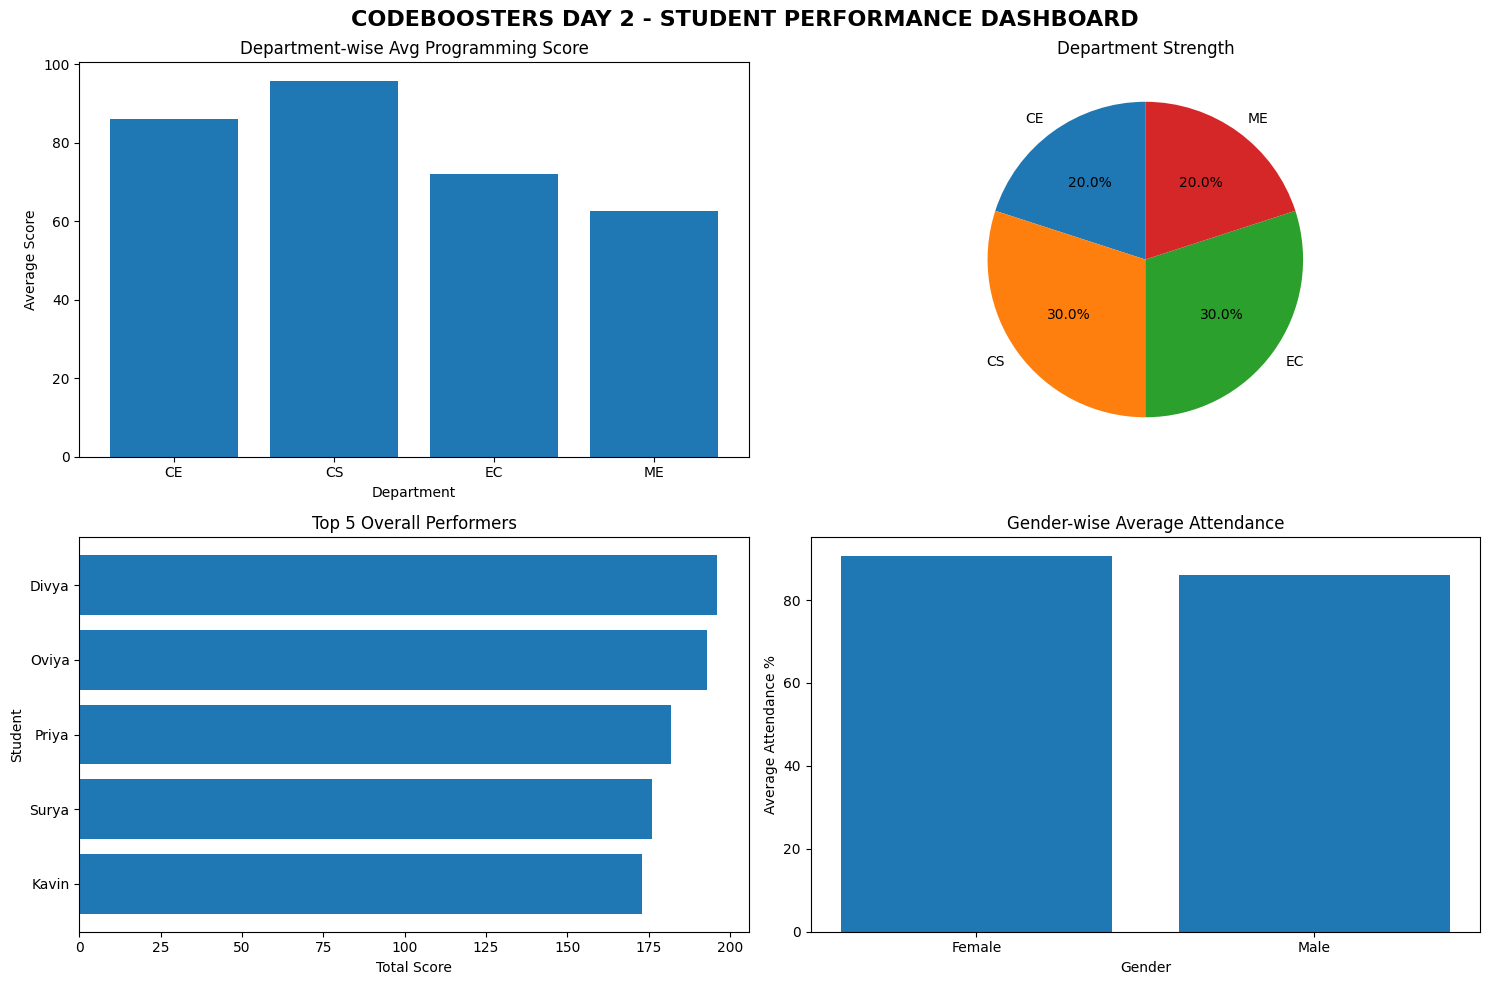

In [8]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Connect database
conn = sqlite3.connect("college.db")

# Create sample students table if missing
students_data = {
    'student_id': [1,2,3,4,5,6,7,8,9,10],
    'name': ['Oviya','Rahul','Ananya','Kavin','Priya','Arun','Meena','Surya','Divya','Vikram'],
    'department': ['CS','EC','ME','CE','CS','EC','ME','CE','CS','EC'],
    'gender': ['Female','Male','Female','Male','Female','Male','Female','Male','Female','Male'],
    'math_score': [95,80,78,88,92,75,81,89,97,76],
    'programming_score': [98,70,65,85,90,72,60,87,99,74],
    'attendance_percentage': [90,85,88,92,95,80,84,91,96,82]
}

students_df = pd.DataFrame(students_data)

students_df['total_score'] = (
    students_df['math_score'] +
    students_df['programming_score']
)

students_df.to_sql('students', conn, if_exists='replace', index=False)

# SQL Queries
avg_prog = pd.read_sql_query("""
SELECT department, AVG(programming_score) AS avg_programming
FROM students
GROUP BY department;
""", conn)

gender_attendance = pd.read_sql_query("""
SELECT gender, AVG(attendance_percentage) AS avg_attendance
FROM students
GROUP BY gender;
""", conn)

top_students = pd.read_sql_query("""
SELECT name, total_score
FROM students
ORDER BY total_score DESC
LIMIT 5;
""", conn)

dept_strength = pd.read_sql_query("""
SELECT department, COUNT(*) AS total_students
FROM students
GROUP BY department;
""", conn)

# Dashboard
plt.figure(figsize=(15, 10))

plt.suptitle("CODEBOOSTERS DAY 2 - STUDENT PERFORMANCE DASHBOARD", fontsize=16, fontweight='bold')

# Panel 1
plt.subplot(2, 2, 1)
plt.bar(avg_prog['department'], avg_prog['avg_programming'])
plt.title("Department-wise Avg Programming Score")
plt.xlabel("Department")
plt.ylabel("Average Score")

# Panel 2
plt.subplot(2, 2, 2)
plt.pie(
    dept_strength['total_students'],
    labels=dept_strength['department'],
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Department Strength")

# Panel 3
plt.subplot(2, 2, 3)
plt.barh(top_students['name'], top_students['total_score'])
plt.title("Top 5 Overall Performers")
plt.xlabel("Total Score")
plt.ylabel("Student")
plt.gca().invert_yaxis()

# Panel 4
plt.subplot(2, 2, 4)
plt.bar(gender_attendance['gender'], gender_attendance['avg_attendance'])
plt.title("Gender-wise Average Attendance")
plt.xlabel("Gender")
plt.ylabel("Average Attendance %")

plt.tight_layout()
plt.show()